In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from sensor.camera_sensor import CameraSensor
import numpy as np
import matplotlib.pyplot as plt

In [2]:
camera = CameraSensor()

In [3]:
# 1. Define a time array (e.g., tracking a 10 millisecond event)
t = np.linspace(0, 10e-3, 500)  # 500 points from 0 to 10 ms

# 2. Simulate a changing plasma power P over that time (a pulse shape)
# Peak power of 80 picowatts, peaking at 4 ms
P_max = 8e-11
P = P_max * np.exp(-((t - 4e-3) / 1.5e-3)**2)


# 3. Pass the array through your CameraSensor instance
photons = camera.photons_from_power(P)
electrons = camera.electrons(photons)
snr = camera.snr(electrons)
sat = camera.saturation_fraction(electrons)

# Plot the SNR

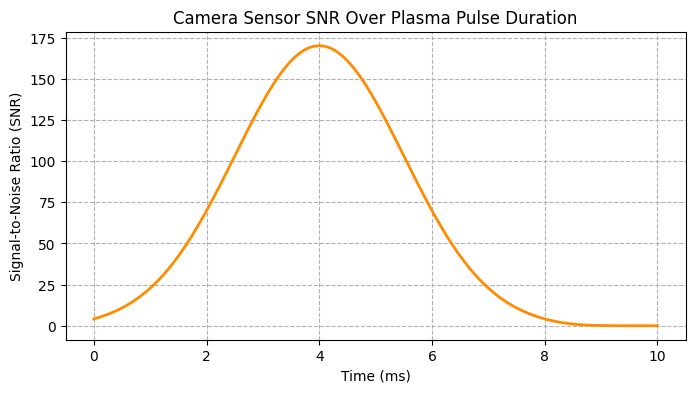

In [4]:
# 4. Now your plot will work perfectly!
plt.figure(figsize=(8,4))
plt.plot(t * 1e3, snr, color='darkorange', lw=2)  # Multiplying t by 1e3 converts it to ms for easy reading

plt.xlabel("Time (ms)")
plt.ylabel("Signal-to-Noise Ratio (SNR)")
plt.title("Camera Sensor SNR Over Plasma Pulse Duration")
plt.grid(True, linestyle='--')
plt.savefig("../figures/camera_sensor_snr_during_pulse.png", dpi='figure', bbox_inches='tight')
plt.show()

## Plot Saturation

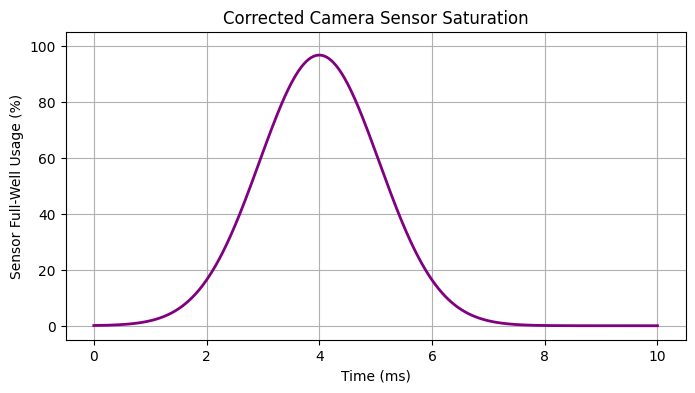

In [5]:
plt.figure(figsize=(8,4))

# plt.plot(t, sat*100)
plt.plot(t * 1e3, sat*100, color='purple', lw=2)  # Multiplying t by 1e3 converts it to ms for easy reading

plt.xlabel("Time (ms)")
plt.ylabel("Sensor Full-Well Usage (%)")
plt.title("Corrected Camera Sensor Saturation")
plt.ylim(-5, 105) # Lock y-axis between 0 and 100%
plt.grid(True)

# For GitHub

In [6]:
t = np.linspace(0, 50, 2000)  # seconds
dt = t[1] - t[0]
q0 = 5e5  # W/m^2 peak heat flux
heat_flux = q0 * np.exp(-((t - 15) / 5)**2) + 0.2 * q0 * np.exp(-((t - 35) / 3)**2)

T0 = 300  # K
C = 5e3   # thermal capacity (J/m^2/K)
R = 2e-4  # thermal resistance (K·m^2/W)

T = np.zeros_like(t)
T[0] = T0

for i in range(1, len(t)):
    dTdt = (heat_flux[i-1] - (T[i-1] - T0)/R) / C
    T[i] = T[i-1] + dTdt * dt

### Optical power model

Assume radiative emission increases strongly with temperature (linearized Stefan-Boltzmann behavior around operating point):

In [7]:
sigma_eff = 1e-10  # effective coupling (toy model scaling)

optical_power = sigma_eff * (T**4 - T0**4)

# clip negatives (numerical stability)
optical_power = np.clip(optical_power, 0, None)

### Camera sensor + SNR model

We include shot noise + read noise:

In [8]:
read_noise = 2e-9  # W equivalent noise floor

shot_noise = np.sqrt(optical_power + 1e-18)

noise = np.sqrt(read_noise**2 + shot_noise**2)

snr = optical_power / noise

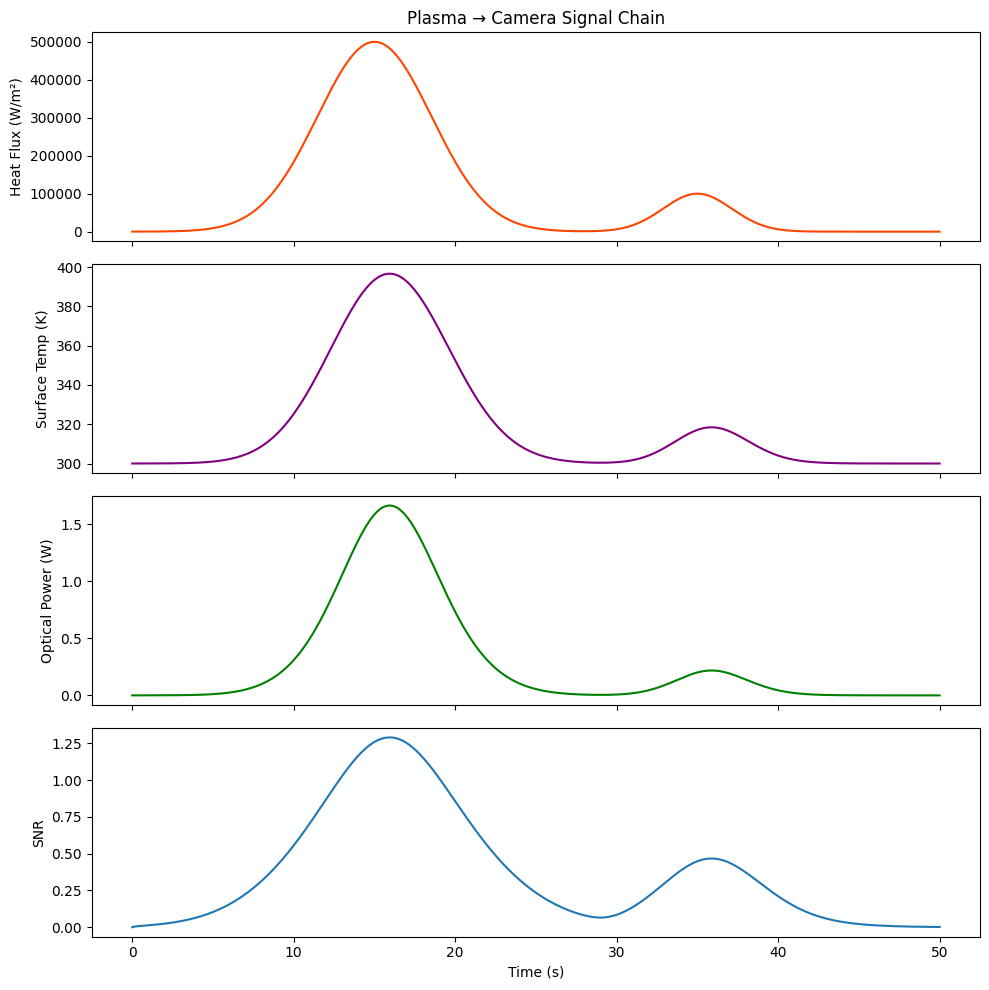

In [11]:
fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

axs[0].plot(t, heat_flux, color="orangered")
axs[0].set_ylabel("Heat Flux (W/m²)")
axs[0].set_title("Plasma → Camera Signal Chain")

axs[1].plot(t, T, color="purple")
axs[1].set_ylabel("Surface Temp (K)")

axs[2].plot(t, optical_power, color="green")
axs[2].set_ylabel("Optical Power (W)")

axs[3].plot(t, snr)
axs[3].set_ylabel("SNR")
axs[3].set_xlabel("Time (s)")

plt.tight_layout()
plt.savefig("../figures/plasma_camera_.png", dpi='figure', bbox_inches='tight')
plt.show()